# TrOCR Beginner Notebook

A step-by-step starter for handwritten OCR with TrOCR.

## What you will do
1. Install tools
2. Run a tiny sample inference
3. Load CSV-based data
4. Fine-tune on your own dataset later

In [1]:
!pip -q install transformers accelerate datasets evaluate jiwer pillow pandas scikit-learn sentencepiece

In [2]:

import os
from pathlib import Path
import pandas as pd
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel


## Project paths

In [3]:

from pathlib import Path

# Project root (works in VS Code, Jupyter, and most notebook setups)
PROJECT_ROOT = Path.cwd().parent

SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
IMG_DIR = SAMPLE_DIR / "images"
CSV_PATH = SAMPLE_DIR / "sample.csv"

print("Project:", PROJECT_ROOT)
print("CSV:", CSV_PATH)
print("Images:", IMG_DIR)

assert CSV_PATH.exists(), f"Missing: {CSV_PATH}"
assert IMG_DIR.exists(), f"Missing: {IMG_DIR}"

print("Everything looks good!")


Project: c:\Users\Aloyson\OneDrive\Documents\AloyImpt\thesis\GitRepo\ocr-thesis-handwritten-forms\trocr_beginner_project
CSV: c:\Users\Aloyson\OneDrive\Documents\AloyImpt\thesis\GitRepo\ocr-thesis-handwritten-forms\trocr_beginner_project\data\sample\sample.csv
Images: c:\Users\Aloyson\OneDrive\Documents\AloyImpt\thesis\GitRepo\ocr-thesis-handwritten-forms\trocr_beginner_project\data\sample\images
Everything looks good!


## Sample test files

In [4]:

# This CSV is for pipeline testing only.
# Later you will replace it with IAM or your own handwritten form crops.
df = pd.read_csv(CSV_PATH)
df


,image_path,text
0,sample_01.png,hello world
1,sample_02.png,bank form
2,sample.png,handwriiten
3,sample2.png,Grocery list


## Load TrOCR

In [5]:

MODEL_NAME = 'microsoft/trocr-base-handwritten'
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

## Run inference on a sample image

Predicted text: hello world 2000


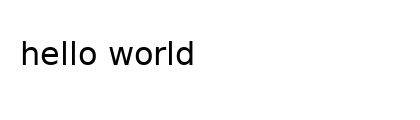

In [6]:

img_path = IMG_DIR / df.loc[0, 'image_path']
image = Image.open(img_path).convert('RGB')
pixel_values = processor(images=image, return_tensors='pt').pixel_values.to(device)

with torch.no_grad():
    generated_ids = model.generate(pixel_values, max_length=64)

pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print('Predicted text:', pred)
image


## Next step

In [7]:

# Replace SAMPLE_DIR with your real IAM or form-field dataset.
# The training pipeline expects CSV columns: image_path,text
